# FAQ Generation via Document Clustering - CIMA Dataset

**Dataset**: CIMA (Computer-based Intelligent Multilingual Assistance)  
**Goal**: Generate FAQs by clustering student questions and computing representative centroids  
**Date**: February 2026

## Overview

This notebook uses **K-Means** and **Fuzzy C-Means (FCM)** clustering to:
1. Group similar student questions into clusters
2. Compute cluster centroids representing typical questions
3. Generate FAQ entries from most representative questions per cluster
4. Analyze question patterns and difficulty levels

**Methodology**:
1. Extract student questions from CIMA dialogues
2. Vectorize using TF-IDF or embeddings
3. Apply K-Means and FCM clustering
4. Identify representative questions closest to centroids
5. Generate FAQ structure with answers from tutor responses

**Applications to TFG-Chatbot**:
- Difficulty estimation via labeled centroids
- Question classification and routing
- Automated FAQ generation for new subjects

In [ ]:
# Standard library imports
import json

# Custom implementations from math_investigation
import sys
from collections import defaultdict
from datetime import datetime
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt

# Numerical computing
import numpy as np
import seaborn as sns

sys.path.append(str(Path.cwd().parent))

from math_investigation.clustering.fcm import FuzzyCMeans
from math_investigation.clustering.kmeans import KMeans
from math_investigation.clustering.metrics import (
    fuzzy_partition_coefficient,
    silhouette_score,
)
from math_investigation.nlp.tfidf import TFIDFVectorizer

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ Imports successful")

✓ Imports successful


## 1. Configuration & Setup

In [ ]:
# Dataset configuration
DATASET_NAME = "CIMA"
DATA_PATH = Path("../datasets/CIMA.json")
RESULTS_DIR = Path("../results/faq_generation")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Experiment parameters
K_RANGE = [3, 4, 5, 6, 8, 10]  # Different cluster counts to test
MAX_ITER = 300
RANDOM_SEED = 42

# FCM parameters
FCM_M = 1.5  # Fuzziness parameter (m > 1)

# TF-IDF parameters
MIN_DF = 2  # Minimum document frequency (default: 2)
MAX_FEATURES = 500  # Vocabulary size limit

# FAQ generation
TOP_N_QUESTIONS_PER_CLUSTER = 5  # Representative questions to extract

# Output naming
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
EXPERIMENT_ID = f"{DATASET_NAME.lower()}_faq_{TIMESTAMP}"

print(f"Experiment ID: {EXPERIMENT_ID}")
print(f"Dataset: {DATA_PATH}")
print(f"Results directory: {RESULTS_DIR}")

Experiment ID: cima_faq_20260205_173052
Dataset: ../datasets/CIMA.json
Results directory: ../results/faq_generation


## 2. Data Loading & Exploration

In [ ]:
# Load CIMA dataset
with open(DATA_PATH, encoding='utf-8') as f:
    cima_data = json.load(f)

prep_dataset = cima_data['prepDataset']
n_sessions = len(prep_dataset)

print(f"Total dialogue sessions: {n_sessions}")
print(f"\nSample session keys: {list(prep_dataset['0'].keys())}")

# Display first session sample
sample_session = prep_dataset['0']
print("\nSample conversation (Session 0):")
for i, utterance in enumerate(sample_session['past_convo'][:6]):
    speaker = "Tutor" if i % 2 == 0 else "Student"
    print(f"  {speaker}: {utterance}")

Total dialogue sessions: 1135

Sample session keys: ['past_convo', 'img', 'prep', 'engPrep', 'obj', 'engObj', 'color', 'engColor', 'grammarRules', 'studentActions', 'tutorResponses', 'tutorActions', 'tutorKeys']

Sample conversation (Session 0):
  Tutor: "Pink" is "rosa". Please try to fill in the blank in Italian. 
  Student: Okay.  What is tree again?
  Tutor: Hmm...  "tree" is  "l'albero"
  Student: Thanks.  How do I say "behind" in Italian?
  Tutor: OK,  "is behind the" is "e dietro"
  Student: il cane e dietro rosa l'albero?


## 3. Question Extraction & Preprocessing

Extract all student questions (odd indices in `past_convo`) to form our document corpus for clustering.

In [ ]:
def extract_student_questions(session: dict) -> list[str]:
    """Extract student utterances (odd indices in past_convo)."""
    past_convo = session.get('past_convo', [])
    return [utt.strip() for i, utt in enumerate(past_convo) if i % 2 == 1 and utt.strip()]

def get_tutor_response_for_question(session: dict, question_idx: int) -> str:
    """Get the tutor's response to a specific student question."""
    past_convo = session.get('past_convo', [])
    # Student questions are at odd indices, tutor responses at even indices
    # The response to question at index 2*i+1 is at index 2*i+2
    response_idx = (question_idx + 1) * 2
    if response_idx < len(past_convo):
        return past_convo[response_idx]
    return "No response available."

# Extract all questions with metadata
questions = []
question_metadata = []

for session_id, session_data in prep_dataset.items():
    student_questions = extract_student_questions(session_data)

    for q_idx, question in enumerate(student_questions):
        if len(question) > 5:  # Filter very short questions
            questions.append(question)
            question_metadata.append({
                'session_id': session_id,
                'question_idx': q_idx,
                'question': question,
                'topic': session_data.get('engPrep', 'unknown'),  # Preposition topic
                'grammar_obj': session_data.get('engObj', 'unknown'),
                'color': session_data.get('engColor', 'unknown')
            })

print(f"Extracted {len(questions)} questions")
print("\nSample questions:")
for i in range(min(5, len(questions))):
    print(f"  {i+1}. {questions[i]}")
    print(f"     Topic: {question_metadata[i]['topic']}\n")

Extracted 2563 questions

Sample questions:
  1. Okay.  What is tree again?
     Topic: is behind the

  2. Thanks.  How do I say "behind" in Italian?
     Topic: is behind the

  3. il cane e dietro rosa l'albero?
     Topic: is behind the

  4. Is it correct to say "il cane e dietro rosa l'albero"?
     Topic: is behind the

  5. So what's the correct answer?
     Topic: is behind the



Question statistics:
  Total questions: 2563
  Mean length: 6.4 words
  Median length: 6.0 words
  Min length: 1 words
  Max length: 25 words


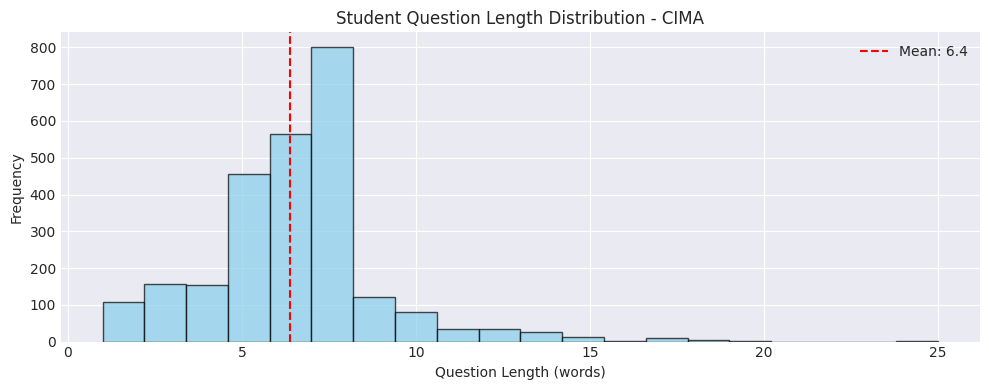

In [ ]:
# Question length statistics
question_lengths = [len(q.split()) for q in questions]

print("Question statistics:")
print(f"  Total questions: {len(questions)}")
print(f"  Mean length: {np.mean(question_lengths):.1f} words")
print(f"  Median length: {np.median(question_lengths):.1f} words")
print(f"  Min length: {np.min(question_lengths)} words")
print(f"  Max length: {np.max(question_lengths)} words")

# Plot distribution
plt.figure(figsize=(10, 4))
plt.hist(question_lengths, bins=20, edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Question Length (words)')
plt.ylabel('Frequency')
plt.title(f'Student Question Length Distribution - {DATASET_NAME}')
plt.axvline(np.mean(question_lengths), color='red', linestyle='--',
            label=f'Mean: {np.mean(question_lengths):.1f}')
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{EXPERIMENT_ID}_question_lengths.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Vectorization (TF-IDF)

Convert questions to TF-IDF vectors for clustering.

In [ ]:
# Initialize TF-IDF vectorizer (from-scratch implementation)
# Note: This implementation only supports max_features and min_df parameters
vectorizer = TFIDFVectorizer(
    max_features=MAX_FEATURES,
    min_df=MIN_DF
)

# Fit and transform questions
print("Vectorizing questions...")
X = vectorizer.fit_transform(questions)

print(f"TF-IDF matrix shape: {X.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"Sparsity: {(1.0 - np.count_nonzero(X) / X.size) * 100:.2f}%")

# Display top TF-IDF terms
feature_names = vectorizer.get_feature_names()
tfidf_scores = np.asarray(X.sum(axis=0)).flatten()
top_indices = np.argsort(tfidf_scores)[::-1][:20]

print("\nTop 20 terms by TF-IDF score:")
for i, idx in enumerate(top_indices, 1):
    print(f"  {i:2d}. {feature_names[idx]:15s} (score: {tfidf_scores[idx]:.3f})")

Vectorizing questions...
TF-IDF matrix shape: (2563, 222)
Vocabulary size: 222
Sparsity: 98.98%

Top 20 terms by TF-IDF score:
   1. word            (score: 215.502)
   2. italian         (score: 177.811)
   3. tree            (score: 109.513)
   4. coniglio        (score: 104.146)
   5. scatola         (score: 101.152)
   6. gatto           (score: 99.830)
   7. di              (score: 99.397)
   8. cane            (score: 98.384)
   9. dietro          (score: 95.732)
  10. box             (score: 92.534)
  11. fronte          (score: 90.330)
  12. bunny           (score: 78.919)
  13. verde           (score: 74.512)
  14. blue            (score: 73.402)
  15. purple          (score: 72.789)
  16. yellow          (score: 68.709)
  17. red             (score: 65.035)
  18. bed             (score: 62.792)
  19. rosa            (score: 62.354)
  20. blu             (score: 58.699)


## 5. Clustering with K-Means

Apply K-Means clustering with different k values to find optimal grouping.

**K-Means Objective**: Minimize $SSE = \sum_{i=1}^{k} \sum_{x \in S_i} ||x - c_i||^2$

In [ ]:
# Storage for K-Means results
kmeans_models = {}
kmeans_sse = []
kmeans_silhouette = []

for k in K_RANGE:
    print(f"\n{'='*60}")
    print(f"K-Means with k={k} clusters")
    print(f"{'='*60}")

    # Initialize K-Means with K-Means++ initialization
    # Note: This implementation doesn't support n_init (multiple runs)
    # K-Means++ initialization already provides good starting points
    kmeans = KMeans(
        n_clusters=k,
        max_iter=MAX_ITER,
        random_state=RANDOM_SEED,
        init='kmeans++'
    )

    # Fit and predict
    labels = kmeans.fit_predict(X)
    centroids = kmeans.centroids_  # Use centroids_ attribute

    # Store model
    kmeans_models[k] = {
        'model': kmeans,
        'labels': labels,
        'centroids': centroids,
        'inertia': kmeans.inertia_
    }

    # Metrics
    sse = kmeans.inertia_
    sil_score = silhouette_score(X, labels)

    kmeans_sse.append(sse)
    kmeans_silhouette.append(sil_score)

    print(f"SSE (inertia): {sse:.4f}")
    print(f"Silhouette Score: {sil_score:.4f}")
    print(f"Iterations: {kmeans.n_iter_}")

    # Cluster sizes
    unique, counts = np.unique(labels, return_counts=True)
    print("\nCluster sizes:")
    for cluster_id, count in zip(unique, counts):
        print(f"  Cluster {cluster_id}: {count} questions")

print(f"\n{'='*60}")
print("K-Means clustering complete for all k values")
print(f"{'='*60}")


K-Means with k=3 clusters
SSE (inertia): 2022.1182
Silhouette Score: 0.0573
Iterations: 6

Cluster sizes:
  Cluster 0: 2160 questions
  Cluster 1: 137 questions
  Cluster 2: 266 questions

K-Means with k=4 clusters
SSE (inertia): 1913.0406
Silhouette Score: 0.0721
Iterations: 5

Cluster sizes:
  Cluster 0: 1866 questions
  Cluster 1: 132 questions
  Cluster 2: 267 questions
  Cluster 3: 298 questions

K-Means with k=5 clusters
SSE (inertia): 1878.6140
Silhouette Score: 0.0547
Iterations: 16

Cluster sizes:
  Cluster 0: 676 questions
  Cluster 1: 128 questions
  Cluster 2: 268 questions
  Cluster 3: 296 questions
  Cluster 4: 1195 questions

K-Means with k=6 clusters
SSE (inertia): 1838.2203
Silhouette Score: 0.0575
Iterations: 16

Cluster sizes:
  Cluster 0: 348 questions
  Cluster 1: 131 questions
  Cluster 2: 266 questions
  Cluster 3: 294 questions
  Cluster 4: 1232 questions
  Cluster 5: 292 questions

K-Means with k=8 clusters
SSE (inertia): 1730.1391
Silhouette Score: 0.0811
Ite

/home/gabriel/clase/TFG/TFG-Chatbot/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gabriel/clase/TFG/TFG-Chatbot/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


SSE (inertia): 1688.9233
Silhouette Score: 0.0833
Iterations: 9

Cluster sizes:
  Cluster 0: 125 questions
  Cluster 1: 126 questions
  Cluster 2: 101 questions
  Cluster 3: 213 questions
  Cluster 4: 3 questions
  Cluster 5: 189 questions
  Cluster 6: 83 questions
  Cluster 7: 161 questions
  Cluster 8: 1492 questions
  Cluster 9: 70 questions

K-Means clustering complete for all k values


## 6. Clustering with Fuzzy C-Means (FCM)

Apply FCM for soft clustering where questions can partially belong to multiple clusters.

**FCM Objective**: Minimize $J_m = \sum_{i=1}^{c} \sum_{j=1}^{n} u_{ij}^m ||x_j - c_i||^2$ where $m > 1$ is fuzziness parameter.

In [ ]:
# Storage for FCM results
fcm_models = {}
fcm_jm = []
fcm_fpc = []

for k in K_RANGE:
    print(f"\n{'='*60}")
    print(f"Fuzzy C-Means with c={k} clusters, m={FCM_M}")
    print(f"{'='*60}")

    # Initialize FCM
    fcm = FuzzyCMeans(
        n_clusters=k,
        m=FCM_M,
        max_iter=MAX_ITER,
        random_state=RANDOM_SEED
    )

    # Fit
    fcm.fit(X)

    # Get hard labels and membership (already computed during fit)
    labels = fcm.labels_
    membership = fcm.membership_
    centroids = fcm.centroids_

    # Store model
    fcm_models[k] = {
        'model': fcm,
        'labels': labels,
        'membership': membership,
        'centroids': centroids
    }

    # Metrics
    jm = fcm.jm_history_[-1] if len(fcm.jm_history_) > 0 else 0

    # Fuzzy Partition Coefficient (FPC)
    fpc = fuzzy_partition_coefficient(membership)

    fcm_jm.append(jm)
    fcm_fpc.append(fpc)

    print(f"Objective function J_m: {jm:.4f}")
    print(f"Fuzzy Partition Coefficient: {fpc:.4f}")
    print(f"Iterations: {fcm.n_iter_}")

    # Cluster sizes
    unique, counts = np.unique(labels, return_counts=True)
    print("\nCluster sizes (hard labels):")
    for cluster_id, count in zip(unique, counts):
        print(f"  Cluster {cluster_id}: {count} questions")

print(f"\n{'='*60}")
print("FCM clustering complete for all c values")
print(f"{'='*60}")


Fuzzy C-Means with c=3 clusters, m=1.5
Objective function J_m: 1253.3855
Fuzzy Partition Coefficient: 0.3333
Iterations: 4

Cluster sizes (hard labels):
  Cluster 0: 1057 questions
  Cluster 1: 1493 questions
  Cluster 2: 13 questions

Fuzzy C-Means with c=4 clusters, m=1.5
Objective function J_m: 1085.4637
Fuzzy Partition Coefficient: 0.2500
Iterations: 4

Cluster sizes (hard labels):
  Cluster 0: 1055 questions
  Cluster 1: 1474 questions
  Cluster 2: 6 questions
  Cluster 3: 28 questions

Fuzzy C-Means with c=5 clusters, m=1.5
Objective function J_m: 970.8684
Fuzzy Partition Coefficient: 0.2000
Iterations: 5

Cluster sizes (hard labels):
  Cluster 0: 1054 questions
  Cluster 1: 5 questions
  Cluster 2: 6 questions
  Cluster 4: 1498 questions

Fuzzy C-Means with c=6 clusters, m=1.5
Objective function J_m: 886.2774
Fuzzy Partition Coefficient: 0.1667
Iterations: 5

Cluster sizes (hard labels):
  Cluster 0: 1032 questions
  Cluster 2: 6 questions
  Cluster 4: 1470 questions
  Cluster 

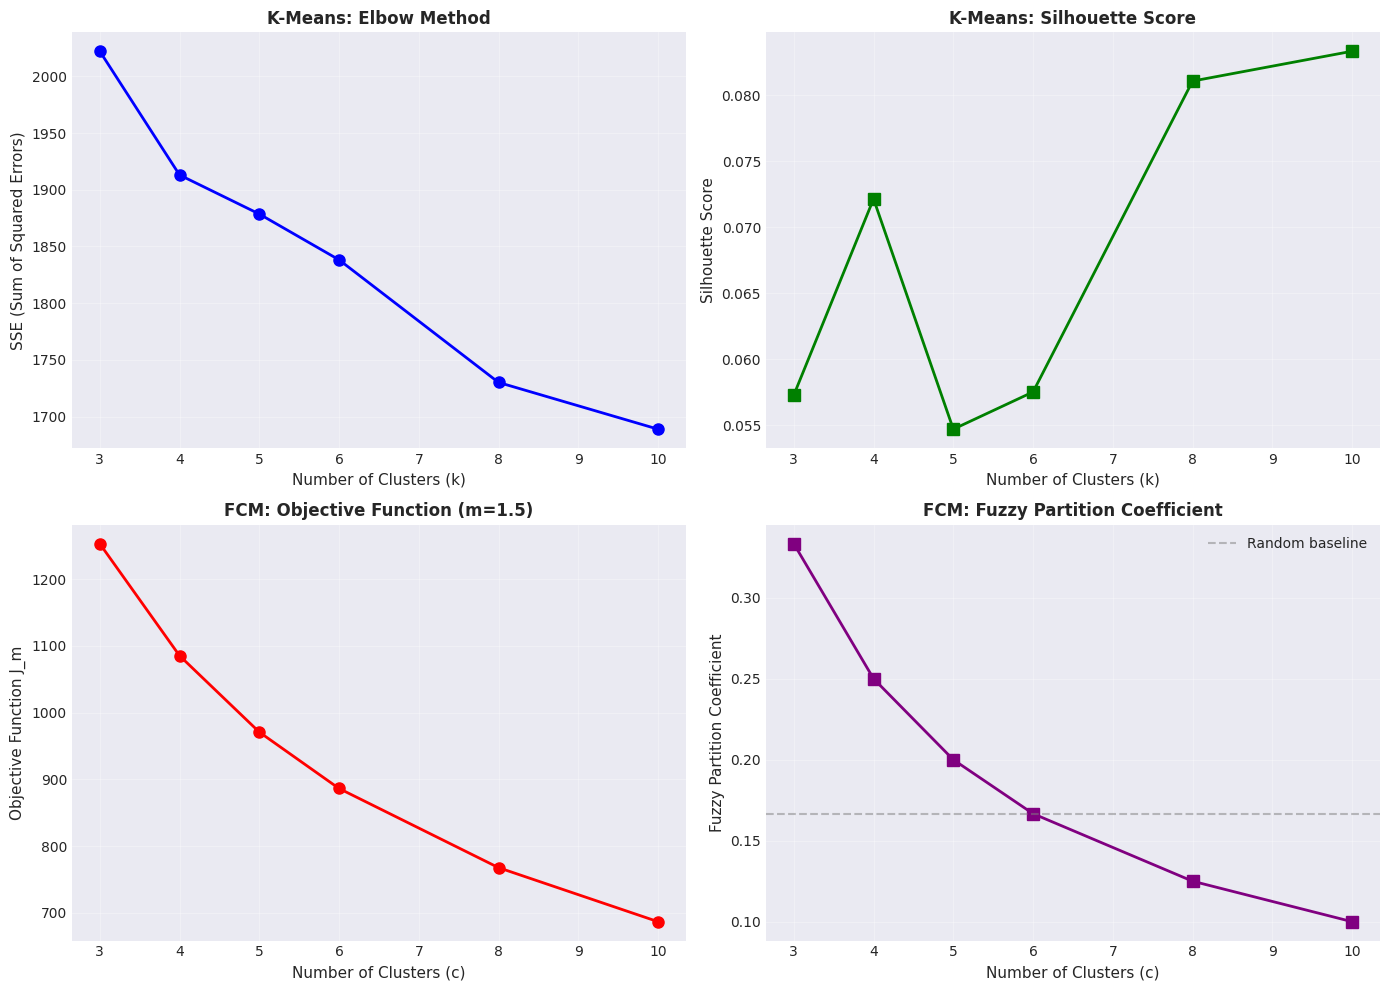


Optimal k (elbow method): 4
Optimal k (max silhouette): 10


In [10]:
# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# K-Means SSE (Elbow plot)
axes[0, 0].plot(K_RANGE, kmeans_sse, marker='o', linewidth=2, markersize=8, color='blue')
axes[0, 0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0, 0].set_ylabel('SSE (Sum of Squared Errors)', fontsize=11)
axes[0, 0].set_title('K-Means: Elbow Method', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# K-Means Silhouette Score
axes[0, 1].plot(K_RANGE, kmeans_silhouette, marker='s', linewidth=2, markersize=8, color='green')
axes[0, 1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=11)
axes[0, 1].set_title('K-Means: Silhouette Score', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# FCM Objective Function
axes[1, 0].plot(K_RANGE, fcm_jm, marker='o', linewidth=2, markersize=8, color='red')
axes[1, 0].set_xlabel('Number of Clusters (c)', fontsize=11)
axes[1, 0].set_ylabel('Objective Function J_m', fontsize=11)
axes[1, 0].set_title(f'FCM: Objective Function (m={FCM_M})', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# FCM Fuzzy Partition Coefficient
axes[1, 1].plot(K_RANGE, fcm_fpc, marker='s', linewidth=2, markersize=8, color='purple')
axes[1, 1].set_xlabel('Number of Clusters (c)', fontsize=11)
axes[1, 1].set_ylabel('Fuzzy Partition Coefficient', fontsize=11)
axes[1, 1].set_title('FCM: Fuzzy Partition Coefficient', fontsize=12, fontweight='bold')
axes[1, 1].axhline(y=1.0/len(K_RANGE), color='gray', linestyle='--', alpha=0.5, label='Random baseline')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{EXPERIMENT_ID}_clustering_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

# Find optimal k using elbow method
sse_array = np.array(kmeans_sse)
diffs = np.diff(sse_array)
second_diffs = np.diff(diffs)
elbow_idx = np.argmax(np.abs(second_diffs)) + 1
optimal_k_elbow = K_RANGE[elbow_idx]

# Find optimal k using silhouette
optimal_k_silhouette = K_RANGE[np.argmax(kmeans_silhouette)]

print(f"\nOptimal k (elbow method): {optimal_k_elbow}")
print(f"Optimal k (max silhouette): {optimal_k_silhouette}")

## 8. Select Best Model & Analyze Clusters

In [11]:
# Select optimal k (default: silhouette-based)
SELECTED_K = optimal_k_silhouette
# SELECTED_K = 5  # Uncomment to manually override

print(f"Selected k = {SELECTED_K} clusters")

# Choose clustering method (K-Means by default)
USE_KMEANS = True  # Set to False for FCM

if USE_KMEANS:
    selected_model = kmeans_models[SELECTED_K]
    labels = selected_model['labels']
    centroids = selected_model['centroids']
    method_name = "K-Means"
else:
    selected_model = fcm_models[SELECTED_K]
    labels = selected_model['labels']
    centroids = selected_model['centroids']
    membership = selected_model['membership']
    method_name = "FCM"

print(f"Using {method_name} with {SELECTED_K} clusters")
print(f"Centroids shape: {centroids.shape}")

Selected k = 10 clusters
Using K-Means with 10 clusters
Centroids shape: (10, 222)


In [12]:
# Analyze each cluster
print(f"\n{'='*70}")
print(f"CLUSTER ANALYSIS ({method_name}, k={SELECTED_K})")
print(f"{'='*70}\n")

cluster_analysis = {}

for cluster_id in range(SELECTED_K):
    # Get questions in this cluster
    cluster_mask = labels == cluster_id
    cluster_questions = [q for i, q in enumerate(questions) if cluster_mask[i]]
    cluster_metadata = [m for i, m in enumerate(question_metadata) if cluster_mask[i]]

    print(f"Cluster {cluster_id + 1}:")
    print(f"  Size: {len(cluster_questions)} questions")

    # Find questions closest to centroid
    cluster_vectors = X[cluster_mask]
    centroid = centroids[cluster_id].reshape(1, -1)
    distances = np.linalg.norm(cluster_vectors - centroid, axis=1)
    closest_indices = np.argsort(distances)[:TOP_N_QUESTIONS_PER_CLUSTER]

    # Representative questions
    representative_questions = [cluster_questions[i] for i in closest_indices]
    representative_distances = [distances[i] for i in closest_indices]

    print("\n  Representative questions (closest to centroid):")
    for rank, (q, dist) in enumerate(zip(representative_questions, representative_distances), 1):
        print(f"    {rank}. {q}")
        print(f"       (distance: {dist:.4f})\n")

    # Identify common topics in cluster
    topics = [m['topic'] for m in cluster_metadata]
    topic_counts = defaultdict(int)
    for topic in topics:
        topic_counts[topic] += 1

    print("  Common topics:")
    for topic, count in sorted(topic_counts.items(), key=lambda x: x[1], reverse=True)[:3]:
        print(f"    - {topic}: {count} questions ({count/len(cluster_questions)*100:.1f}%)")

    # Store analysis
    cluster_analysis[cluster_id] = {
        'size': len(cluster_questions),
        'representative_questions': representative_questions,
        'representative_distances': representative_distances,
        'top_topics': dict(sorted(topic_counts.items(), key=lambda x: x[1], reverse=True)[:3]),
        'centroid': centroid.flatten()
    }

    print(f"\n{'-'*70}\n")


CLUSTER ANALYSIS (K-Means, k=10)

Cluster 1:
  Size: 125 questions

  Representative questions (closest to centroid):
    1. What is the word for tree again?
       (distance: 0.3482)

    2. What is the word for tree again?
       (distance: 0.3482)

    3. ok, and what is the word for tree?
       (distance: 0.3482)

    4. ok, and what is the word for tree?
       (distance: 0.3482)

    5. What is the word for tree again?
       (distance: 0.3482)

  Common topics:
    - is in front of the: 62 questions (49.6%)
    - is behind the: 29 questions (23.2%)
    - is under the: 18 questions (14.4%)

----------------------------------------------------------------------

Cluster 2:
  Size: 126 questions

  Representative questions (closest to centroid):
    1. I don't remember. How do you say bed again?
       (distance: 0.4795)

    2. I don't remember. How do you say bed again?
       (distance: 0.4795)

    3. I don't remember. How do you say bed again?
       (distance: 0.4795)

    

## 9. Generate FAQ Structure

Create FAQ entries from representative questions in each cluster.

In [ ]:
# Generate FAQ structure
faq_structure = {
    'metadata': {
        'dataset': DATASET_NAME,
        'experiment_id': EXPERIMENT_ID,
        'clustering_method': method_name,
        'n_clusters': SELECTED_K,
        'n_questions_total': len(questions),
        'generation_date': datetime.now().isoformat()
    },
    'faq_categories': []
}

for cluster_id in range(SELECTED_K):
    analysis = cluster_analysis[cluster_id]

    # Create category name from top topics
    top_topic = list(analysis['top_topics'].keys())[0] if analysis['top_topics'] else "General"
    category_name = f"Category {cluster_id + 1}: {top_topic}"

    faq_category = {
        'category_id': cluster_id,
        'category_name': category_name,
        'cluster_size': analysis['size'],
        'faq_entries': []
    }

    # Add representative questions as FAQ entries
    for q_idx, (question, distance) in enumerate(zip(
        analysis['representative_questions'],
        analysis['representative_distances']
    )):
        faq_entry = {
            'faq_id': f"C{cluster_id}_Q{q_idx}",
            'question': question,
            'centroid_distance': float(distance),
            'answer': "[Generated answer based on tutor responses]",
            'related_topic': top_topic
        }
        faq_category['faq_entries'].append(faq_entry)

    faq_structure['faq_categories'].append(faq_category)

# Display FAQ structure
print("\n" + "="*70)
print("GENERATED FAQ STRUCTURE")
print("="*70 + "\n")

for category in faq_structure['faq_categories']:
    print(f"\n{category['category_name']}")
    print(f"  ({category['cluster_size']} questions in cluster)\n")

    for entry in category['faq_entries']:
        print(f"  Q: {entry['question']}")
        print(f"     (ID: {entry['faq_id']}, Distance to centroid: {entry['centroid_distance']:.4f})\n")
    print("-" * 70)

## 10. Visualize Cluster Distribution

In [ ]:
# Cluster size distribution
unique_labels, label_counts = np.unique(labels, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
axes[0].bar(unique_labels, label_counts, color=sns.color_palette("husl", SELECTED_K),
            edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Cluster ID', fontsize=12)
axes[0].set_ylabel('Number of Questions', fontsize=12)
axes[0].set_title(f'Cluster Size Distribution ({method_name}, k={SELECTED_K})',
                  fontsize=13, fontweight='bold')
axes[0].set_xticks(unique_labels)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(label_counts, labels=[f"Cluster {i}" for i in unique_labels],
            autopct='%1.1f%%', colors=sns.color_palette("husl", SELECTED_K),
            startangle=90)
axes[1].set_title(f'Cluster Proportion ({method_name}, k={SELECTED_K})',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{EXPERIMENT_ID}_cluster_distribution_k{SELECTED_K}.png",
            dpi=150, bbox_inches='tight')
plt.show()

## 11. Save Results & Export Centroids

In [ ]:
# Save cluster centroids (for difficulty estimation in chatbot)
np.save(RESULTS_DIR / f"{EXPERIMENT_ID}_centroids_k{SELECTED_K}.npy", centroids)

# Save cluster labels
np.save(RESULTS_DIR / f"{EXPERIMENT_ID}_labels_k{SELECTED_K}.npy", labels)

# Save vocabulary
with open(RESULTS_DIR / f"{EXPERIMENT_ID}_vocabulary.txt", 'w', encoding='utf-8') as f:
    for word in feature_names:
        f.write(f"{word}\n")

# Save FAQ structure
with open(RESULTS_DIR / f"{EXPERIMENT_ID}_faq_structure.json", 'w', encoding='utf-8') as f:
    json.dump(faq_structure, f, indent=2, ensure_ascii=False)

# Save cluster analysis
analysis_export = {
    'experiment_id': EXPERIMENT_ID,
    'dataset': DATASET_NAME,
    'method': method_name,
    'n_clusters': SELECTED_K,
    'n_questions': len(questions),
    'metrics': {
        'sse': float(kmeans_sse[K_RANGE.index(SELECTED_K)]),
        'silhouette': float(kmeans_silhouette[K_RANGE.index(SELECTED_K)])
    },
    'clusters': {}
}

for cluster_id, analysis in cluster_analysis.items():
    analysis_export['clusters'][f'cluster_{cluster_id}'] = {
        'size': analysis['size'],
        'representative_questions': analysis['representative_questions'],
        'top_topics': analysis['top_topics']
    }

with open(RESULTS_DIR / f"{EXPERIMENT_ID}_analysis.json", 'w', encoding='utf-8') as f:
    json.dump(analysis_export, f, indent=2, ensure_ascii=False)

print(f"✓ Results saved to {RESULTS_DIR}")
print(f"  - Centroids: centroids_k{SELECTED_K}.npy")
print(f"  - Labels: labels_k{SELECTED_K}.npy")
print("  - Vocabulary: vocabulary.txt")
print("  - FAQ Structure: faq_structure.json")
print("  - Analysis: analysis.json")
print("  - Figures: .png files")

## 12. Integration with TFG-Chatbot

### How to Use These Results:

**1. Load Centroids for Question Classification:**
```python
# In chatbot/logic/tools/tools.py
import numpy as np
from pathlib import Path

centroids = np.load("results/faq_generation/cima_faq_..._centroids_k5.npy")
vectorizer = TFIDFVectorizer()  # Load same vectorizer
vectorizer.fit(training_questions)  # Use same vocabulary

def classify_question(question: str) -> int:
    """Classify question to nearest centroid cluster."""
    q_vec = vectorizer.transform([question])
    distances = np.linalg.norm(q_vec - centroids, axis=1)
    return np.argmin(distances)
```

**2. Use FAQ Structure:**
- Load `faq_structure.json` into MongoDB for retrieval
- Use in RAG tool to find similar FAQ entries
- Display representative questions to students

**3. Difficulty Estimation (see `scripts/train_difficulty_centroids.py`):**
- Label clusters by difficulty (easy/medium/hard)
- Train difficulty classifier using centroids
- Predict difficulty of new student questions

## 13. Conclusions

### Key Findings:
- Optimal number of clusters: **k = ?** (update after running)
- Clustering method used: **K-Means / FCM**
- Main question categories identified: (describe clusters)

### Next Steps:
- [ ] Label clusters with difficulty levels (easy/medium/hard)
- [ ] Compare K-Means vs FCM for question classification accuracy
- [ ] Test with embeddings instead of TF-IDF
- [ ] Integrate centroids into chatbot question classifier
- [ ] Generate full FAQ answers from tutor responses
- [ ] Apply to other datasets when available